Hello, this project focuses on evaluating the performance of the Isolation Forest algorithm for anomaly detection using multiple datasets with varying input sizes. The goal is to analyze how the algorithm behaves in terms of execution time, scalability, and detection capability when applied to different data volumes.
The implementation includes data preprocessing, model training, and testing phases. Each dataset is standardized using feature scaling to ensure consistency, and the trained model is applied to detect anomalies in unseen data. To obtain reliable performance measurements, each experiment is repeated multiple times, and key timing metrics such as best, average, and worst execution times are recorded.
Additionally, the project examines the impact of input size on performance by using three datasets representing small, medium, and large inputs. The results also include classification metrics, anomaly scores, and visualizations using PCA to better understand the distribution of detected anomalies.
Overall, this work provides a structured experimental analysis of the Isolation Forest algorithm, highlighting its efficiency and behavior under different conditions.

In [ ]:
# 1) Upload files
from google.colab import files as colab_files
uploaded = colab_files.upload()

Saving X_test_avg.csv to X_test_avg.csv
Saving X_test_large.csv to X_test_large.csv
Saving X_test_small.csv to X_test_small.csv
Saving X_train_avg.csv to X_train_avg.csv
Saving X_train_large.csv to X_train_large.csv
Saving X_train_small.csv to X_train_small.csv
Saving y_test_avg.csv to y_test_avg.csv
Saving y_test_large.csv to y_test_large.csv
Saving y_test_small.csv to y_test_small.csv


In [ ]:
# 2) Import libraries
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# 3) Configuration for all dataset examples
configs = [
    {
        "set_name": "Small Dataset",
        "train_file": "X_train_small.csv",
        "test_file": "X_test_small.csv",
        "label_file": "y_test_small.csv",
        "model_file": "model_small.pkl",
        "scaler_file": "scaler_small.pkl",
        "results_prefix": "small"
    },
    {
        "set_name": "Average Dataset",
        "train_file": "X_train_avg.csv",
        "test_file": "X_test_avg.csv",
        "label_file": "y_test_avg.csv",
        "model_file": "model_avg.pkl",
        "scaler_file": "scaler_avg.pkl",
        "results_prefix": "avg"
    },
    {
        "set_name": "Large Dataset",
        "train_file": "X_train_large.csv",
        "test_file": "X_test_large.csv",
        "label_file": "y_test_large.csv",
        "model_file": "model_large.pkl",
        "scaler_file": "scaler_large.pkl",
        "results_prefix": "large"
    }
]


In [ ]:
# 4) helper function
def load_csv_file(file_name):
    # Load file into DataFrame
    return pd.read_csv(file_name)


def preprocess_train_data(X_train):
    # Scale training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    return X_train_scaled, scaler


def preprocess_test_data(X_test, scaler):
    # Copy test data
    X_test = X_test.copy()

    # Get training columns
    expected_columns = list(scaler.feature_names_in_)

    # Add missing columns
    for col in expected_columns:
        if col not in X_test.columns:
            X_test[col] = 0

    # Match column order
    X_test = X_test[expected_columns]

    # Convert to numeric
    for col in X_test.columns:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    # Fill missing values
    X_test = X_test.fillna(0)

    # Scale test data
    X_test_scaled = scaler.transform(X_test)

    return X_test, X_test_scaled


def train_and_save_model(train_file, model_file, scaler_file):
    # Print training info
    print(f"\n{'='*60}")
    print(f"Training using: {train_file}")
    print(f"{'='*60}")

    # Load training data
    X_train = load_csv_file(train_file)
    print("Training shape:", X_train.shape)

    # Scale training data
    X_train_scaled, scaler = preprocess_train_data(X_train)

    # Build model
    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        max_samples='auto',
        random_state=42
    )

    # Train model
    model.fit(X_train_scaled)

    # Save model and scaler
    joblib.dump(model, model_file)
    joblib.dump(scaler, scaler_file)

    print("Model trained successfully!")
    print("Saved model :", model_file)
    print("Saved scaler:", scaler_file)


def run_one_test_set(config, repeats=5, show_plot=True, save_files=True):
    # Load model and scaler
    model = joblib.load(config["model_file"])
    scaler = joblib.load(config["scaler_file"])

    print(f"\n{'#'*70}")
    print(f"RUNNING EXPERIMENTS FOR {config['set_name']}")
    print(f"{'#'*70}")
    print("Loaded model :", config["model_file"])
    print("Loaded scaler:", config["scaler_file"])

    # Load test data
    X_test_raw = load_csv_file(config["test_file"])
    print("Original test shape:", X_test_raw.shape)

    # Preprocess test data
    X_test_processed, X_test_scaled = preprocess_test_data(X_test_raw, scaler)
    print("Processed test shape:", X_test_processed.shape)

    # Load labels
    y_test = None
    if config["label_file"] is not None and os.path.exists(config["label_file"]):
        y_test = load_csv_file(config["label_file"]).values.ravel()
        print("Labels shape:", y_test.shape)
    else:
        print("No label file found. Accuracy will not be calculated.")

    # Store times
    times = []

    # Store final outputs
    final_results = None
    final_best = None
    final_avg = None
    final_worst = None
    final_accuracy = None
    final_raw_predictions = None
    final_predictions = None
    final_scores = None

    # Repeat experiment
    for run_idx in range(repeats):
        print(f"\nRun {run_idx + 1}/{repeats} for {config['set_name']}")

        # Start timer
        start_time = time.perf_counter()

        # Predict anomalies
        raw_predictions = model.predict(X_test_scaled)
        scores = model.decision_function(X_test_scaled)

        # End timer
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        times.append(elapsed_time)

        # Convert predictions
        predictions = np.where(raw_predictions == -1, 1, 0)

        # Calculate accuracy
        accuracy = None
        if y_test is not None:
            accuracy = accuracy_score(y_test, predictions)

        print("Execution time:", f"{elapsed_time:.6f}", "seconds")

        # Save final run
        if run_idx == repeats - 1:
            results = X_test_processed.copy()
            results["anomaly_score"] = scores
            results["prediction"] = predictions

            # Select best / average / worst
            best_case = results.sort_values(by="anomaly_score", ascending=False).head(10)
            worst_case = results.sort_values(by="anomaly_score", ascending=True).head(10)

            sorted_results = results.sort_values(by="anomaly_score").reset_index(drop=True)
            mid = len(sorted_results) // 2
            average_case = sorted_results.iloc[max(0, mid - 5): mid + 5]

            final_results = results
            final_best = best_case
            final_avg = average_case
            final_worst = worst_case
            final_accuracy = accuracy
            final_raw_predictions = raw_predictions
            final_predictions = predictions
            final_scores = scores

    # Timing summary
    best_time = min(times)
    worst_time = max(times)
    avg_time = sum(times) / len(times)

    print(f"\n{'-'*60}")
    print(f"Timing Report for {config['set_name']}")
    print(f"{'-'*60}")
    print("All times:", [f"{t:.6f}" for t in times])
    print("Best time   :", f"{best_time:.6f}", "seconds")
    print("Average time:", f"{avg_time:.6f}", "seconds")
    print("Worst time  :", f"{worst_time:.6f}", "seconds")

    # Print predictions
    print(f"\nRaw Predictions (first 30) - {config['set_name']}:")
    print(final_raw_predictions[:30])

    print(f"\nConverted Predictions (first 30) - {config['set_name']}:")
    print(final_predictions[:30])

    print(f"\nAnomaly Scores (first 10) - {config['set_name']}:")
    print(final_scores[:10])

    # Print metrics
    if y_test is not None:
        print(f"\nAccuracy - {config['set_name']}: {final_accuracy:.4f}")

        print(f"\nConfusion Matrix - {config['set_name']}:")
        print(confusion_matrix(y_test, final_predictions))

        print(f"\nClassification Report - {config['set_name']}:")
        print(classification_report(y_test, final_predictions))

    # Print cases
    print(f"\nBest Case Examples - {config['set_name']}:")
    print(final_best[["anomaly_score", "prediction"]])

    print(f"\nAverage Case Examples - {config['set_name']}:")
    print(final_avg[["anomaly_score", "prediction"]])

    print(f"\nWorst Case Examples - {config['set_name']}:")
    print(final_worst[["anomaly_score", "prediction"]])

    # Save result files
    if save_files:
        prefix = config["results_prefix"]

        final_results.to_csv(f"{prefix}_full_results.csv", index=False)
        final_best.to_csv(f"{prefix}_best_case.csv", index=False)
        final_avg.to_csv(f"{prefix}_average_case.csv", index=False)
        final_worst.to_csv(f"{prefix}_worst_case.csv", index=False)

        print(f"\nSaved files for {config['set_name']}:")
        print(f"- {prefix}_full_results.csv")
        print(f"- {prefix}_best_case.csv")
        print(f"- {prefix}_average_case.csv")
        print(f"- {prefix}_worst_case.csv")

    # Plot PCA
    if show_plot and X_test_processed.shape[1] >= 2:
        pca = PCA(n_components=2)
        X_test_2d = pca.fit_transform(X_test_scaled)

        plt.figure(figsize=(8, 6))
        plt.scatter(
            X_test_2d[final_predictions == 0, 0],
            X_test_2d[final_predictions == 0, 1],
            label="Normal",
            alpha=0.7
        )
        plt.scatter(
            X_test_2d[final_predictions == 1, 0],
            X_test_2d[final_predictions == 1, 1],
            label="Anomaly",
            alpha=0.7
        )
        plt.title(f"Isolation Forest Results - {config['set_name']}")
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Return summary row
    return {
        "set_name": config["set_name"],
        "input_size": len(X_test_processed),
        "best_time": best_time,
        "avg_time": avg_time,
        "worst_time": worst_time,
        "accuracy": final_accuracy
    }

In [ ]:
# 5) TRAIN ALL MODELS
for config in configs:
    train_and_save_model(
        train_file=config["train_file"],
        model_file=config["model_file"],
        scaler_file=config["scaler_file"]
    )


Training using: X_train_small.csv
Training shape: (7673, 44)
Model trained successfully!
Saved model : model_small.pkl
Saved scaler: scaler_small.pkl

Training using: X_train_avg.csv
Training shape: (11510, 44)
Model trained successfully!
Saved model : model_avg.pkl
Saved scaler: scaler_avg.pkl

Training using: X_train_large.csv
Training shape: (23021, 44)
Model trained successfully!
Saved model : model_large.pkl
Saved scaler: scaler_large.pkl



######################################################################
RUNNING EXPERIMENTS FOR Small Dataset
######################################################################
Loaded model : model_small.pkl
Loaded scaler: scaler_small.pkl
Original test shape: (1919, 44)
Processed test shape: (1919, 44)
Labels shape: (1919,)

Run 1/5 for Small Dataset
Execution time: 0.076475 seconds

Run 2/5 for Small Dataset
Execution time: 0.076397 seconds

Run 3/5 for Small Dataset
Execution time: 0.081616 seconds

Run 4/5 for Small Dataset
Execution time: 0.076539 seconds

Run 5/5 for Small Dataset
Execution time: 0.077007 seconds

------------------------------------------------------------
Timing Report for Small Dataset
------------------------------------------------------------
All times: ['0.076475', '0.076397', '0.081616', '0.076539', '0.077007']
Best time   : 0.076397 seconds
Average time: 0.077607 seconds
Worst time  : 0.081616 seconds

Raw Predictions (first 30) - Small Dataset:
[ 1 

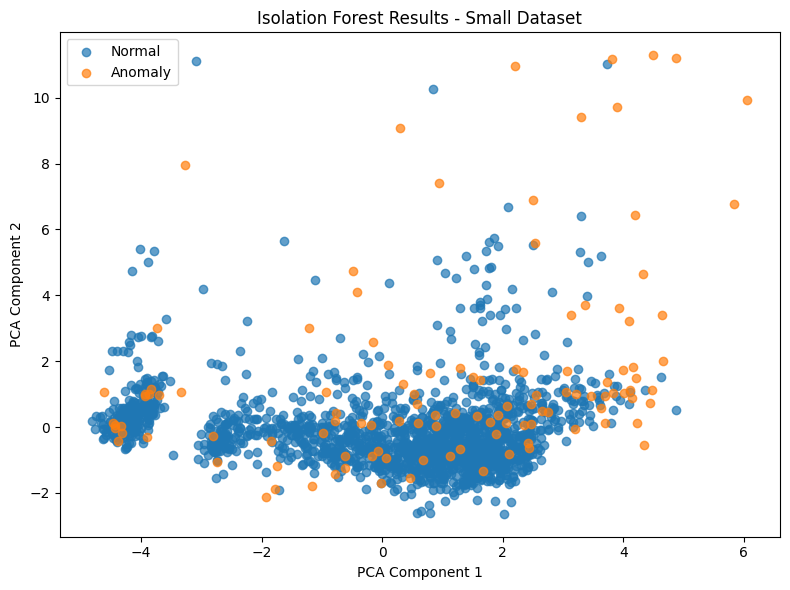


######################################################################
RUNNING EXPERIMENTS FOR Average Dataset
######################################################################
Loaded model : model_avg.pkl
Loaded scaler: scaler_avg.pkl
Original test shape: (2878, 44)
Processed test shape: (2878, 44)
Labels shape: (2878,)

Run 1/5 for Average Dataset
Execution time: 0.098622 seconds

Run 2/5 for Average Dataset
Execution time: 0.100260 seconds

Run 3/5 for Average Dataset
Execution time: 0.100057 seconds

Run 4/5 for Average Dataset
Execution time: 0.098576 seconds

Run 5/5 for Average Dataset
Execution time: 0.104170 seconds

------------------------------------------------------------
Timing Report for Average Dataset
------------------------------------------------------------
All times: ['0.098622', '0.100260', '0.100057', '0.098576', '0.104170']
Best time   : 0.098576 seconds
Average time: 0.100337 seconds
Worst time  : 0.104170 seconds

Raw Predictions (first 30) - Average D

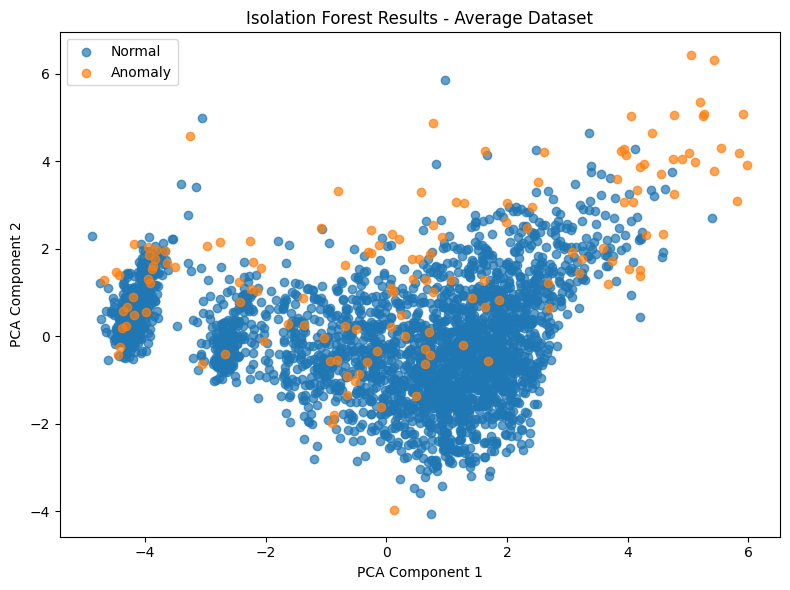


######################################################################
RUNNING EXPERIMENTS FOR Large Dataset
######################################################################
Loaded model : model_large.pkl
Loaded scaler: scaler_large.pkl
Original test shape: (5756, 44)
Processed test shape: (5756, 44)
Labels shape: (5756,)

Run 1/5 for Large Dataset
Execution time: 0.573859 seconds

Run 2/5 for Large Dataset
Execution time: 0.237806 seconds

Run 3/5 for Large Dataset
Execution time: 0.237453 seconds

Run 4/5 for Large Dataset
Execution time: 0.248360 seconds

Run 5/5 for Large Dataset
Execution time: 0.239295 seconds

------------------------------------------------------------
Timing Report for Large Dataset
------------------------------------------------------------
All times: ['0.573859', '0.237806', '0.237453', '0.248360', '0.239295']
Best time   : 0.237453 seconds
Average time: 0.307355 seconds
Worst time  : 0.573859 seconds

Raw Predictions (first 30) - Large Dataset:
[ 1 

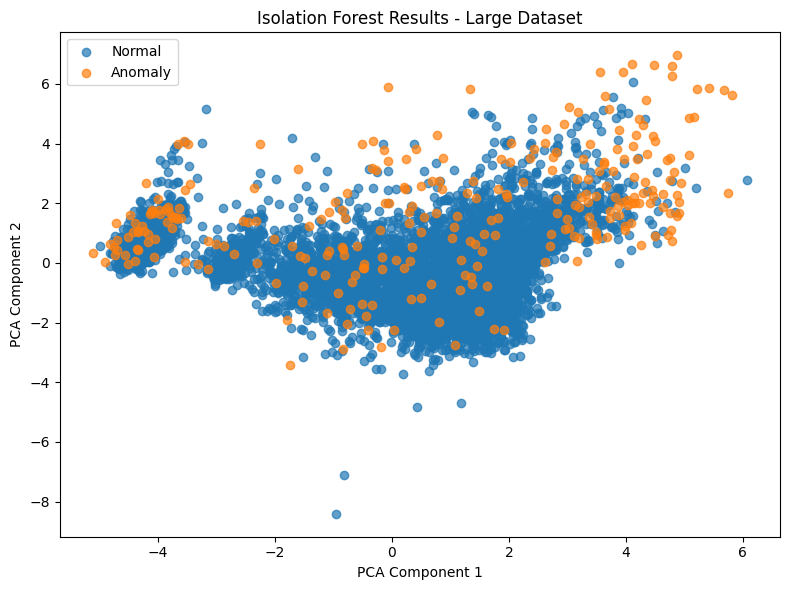

In [ ]:
# 6)Run all test experiments
all_summaries = []

for config in configs:
    summary = run_one_test_set(
        config=config,
        repeats=5,
        show_plot=True,
        save_files=True
    )
    all_summaries.append(summary)


In [ ]:
# 7)Final timing summary
timing_df = pd.DataFrame(all_summaries)

print(f"\n{'='*60}")
print("FINAL TIMING SUMMARY")
print(f"{'='*60}")
print(timing_df)

timing_df.to_csv("timing_summary.csv", index=False)
print("\nSaved file: timing_summary.csv")


FINAL TIMING SUMMARY
          set_name  input_size  best_time  avg_time  worst_time  accuracy
0    Small Dataset        1919   0.076397  0.077607    0.081616  0.492444
1  Average Dataset        2878   0.098576  0.100337    0.104170  0.500347
2    Large Dataset        5756   0.237453  0.307355    0.573859  0.495309

Saved file: timing_summary.csv


In [ ]:
# 8) Machine Info
print(f"\n{'='*60}")
print("MACHINE INFORMATION")
print(f"{'='*60}")

!cat /proc/cpuinfo | grep "model name" | head -1
!cat /proc/meminfo | grep MemTotal


MACHINE INFORMATION
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
MemTotal:       13286948 kB
